# **MSDS-696 Data Science Practicum-2: Multi-Class Infrastructure Damage Classification using Remote Aerial Sensing**

## **Notebook-1: Dataset Loadng, Preprocessing and Data Augmentation**

`Author: Chennakeshava Akhil Pillalamarri`

`Regis University`

This is the first notebook for my capstone project. The goal here is to load the LADI v2 dataset, figure out how to map the labels into the three damage classes I need, preprocess all the images, and save everything to disk so the later training notebooks can just read from folders directly.

## **1. Importing Libraries:**

Importing all required libraries for image processing, dataset loading, visualization, and file management.

In [ ]:
import os
import cv2
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
warnings.filterwarnings('ignore')

from PIL import Image
from io import BytesIO
from datasets import load_dataset

Setting the base working directory for the project. All outputs including all preprocessed images, CSVs, and plots will be saved to this path in the relative folders.

In [2]:
base_path = r"C:\Users\kesha\Desktop\MSDS-696_DSP-2"
os.makedirs(base_path, exist_ok=True)
os.chdir(base_path)
print(os.getcwd())

C:\Users\kesha\Desktop\MSDS-696_DSP-2


## **Loading the Dataset:**

The `LADI v2 (Low Altitude Disaster Imagery version 2)` dataset will be loaded directly from HuggingFace using the `datasets` library. This is a federal government dataset collected by Civil Air Patrol pilots across federally declared US disasters from 2015 to 2023, developed by MIT Lincoln Laboratory.

In [3]:
ds = load_dataset("MITLL/LADI-v2-dataset")
print(ds)

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/40 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'bridges_any', 'buildings_any', 'buildings_affected_or_greater', 'buildings_minor_or_greater', 'debris_any', 'flooding_any', 'flooding_structures', 'roads_any', 'roads_damage', 'trees_any', 'trees_damage', 'water_any'],
        num_rows: 8030
    })
    validation: Dataset({
        features: ['image', 'bridges_any', 'buildings_any', 'buildings_affected_or_greater', 'buildings_minor_or_greater', 'debris_any', 'flooding_any', 'flooding_structures', 'roads_any', 'roads_damage', 'trees_any', 'trees_damage', 'water_any'],
        num_rows: 890
    })
    test: Dataset({
        features: ['image', 'bridges_any', 'buildings_any', 'buildings_affected_or_greater', 'buildings_minor_or_greater', 'debris_any', 'flooding_any', 'flooding_structures', 'roads_any', 'roads_damage', 'trees_any', 'trees_damage', 'water_any'],
        num_rows: 1049
    })
})


In [5]:
train_df = ds['train'].remove_columns(['image']).to_pandas()
val_df   = ds['validation'].remove_columns(['image']).to_pandas()
test_df  = ds['test'].remove_columns(['image']).to_pandas()

print(train_df.shape, val_df.shape, test_df.shape)
print(train_df.columns.tolist())

(8030, 12) (890, 12) (1049, 12)
['bridges_any', 'buildings_any', 'buildings_affected_or_greater', 'buildings_minor_or_greater', 'debris_any', 'flooding_any', 'flooding_structures', 'roads_any', 'roads_damage', 'trees_any', 'trees_damage', 'water_any']


The dataset is pre-split into train (8,030), validation (890), and test (1,049) images following an 80/9/11 ratio defined by MIT Lincoln Laboratory. Each image is accompanied by 12 binary infrastructure label columns.

This split was kept as-is throughout the entire project. Since the split was defined by the original dataset authors who designed it specifically for this data, there was no justification for modifying it, doing so could introduce bias or compromise the integrity of the final evaluation.

## **Extracting Labels and Checking for Nulls**

Removed the image column to get just the label DataFrames for each split so I can work with them easily. Also running a null check here to make sure there are no missing values in the label columns before start mapping classes. Everything came back as 0 nulls so the data is clean.

In [6]:
print(train_df.isnull().sum())

bridges_any                      0
buildings_any                    0
buildings_affected_or_greater    0
buildings_minor_or_greater       0
debris_any                       0
flooding_any                     0
flooding_structures              0
roads_any                        0
roads_damage                     0
trees_any                        0
trees_damage                     0
water_any                        0
dtype: int64


## **Mapping the Binary Labels to Damage Classes**

The dataset gives 12 binary label columns per image but I need just three classes — Intact, Major Damage, and Structural Failure — which match the official FEMA Preliminary Damage Assessment scale.

I will map them like this:
- If `buildings_affected_or_greater` is True → **Structural Failure**
- If `buildings_minor_or_greater` is True → **Major Damage**
- Everything else → **Intact**

I will use np.select() so that Structural Failure takes priority over Major Damage when both could apply.

In [7]:
def get_damage_class(df):
    conditions = [
        (df['buildings_affected_or_greater'] == True) & (df['buildings_minor_or_greater'] == False),
        df['buildings_minor_or_greater'] == True,
    ]
    choices = ['Structural_Failure', 'Major_Damage']
    return np.select(conditions, choices, default='Intact')

train_df['damage_class'] = get_damage_class(train_df)
val_df['damage_class']   = get_damage_class(val_df)
test_df['damage_class']  = get_damage_class(test_df)

print(train_df['damage_class'].value_counts())

damage_class
Intact                6542
Structural_Failure    1012
Major_Damage           476
Name: count, dtype: int64


## 6. Checking the Class Distribution

After mapping, I will print the value counts to see how the classes are distributed.

In [8]:
print(train_df['damage_class'].value_counts(normalize=True) * 100)

damage_class
Intact                81.469489
Structural_Failure    12.602740
Major_Damage           5.927771
Name: proportion, dtype: float64


The imbalance is pretty significant. Intact makes up 81.5% of the training data, while Major Damage is only 5.9%.

Saving the train, val, and test DataFrames to CSV so I can reference the ground 
truth labels from any notebook without having to reload the full HuggingFace 
dataset every time.

In [9]:
train_df.to_csv(os.path.join(base_path, 'train.csv'), index=False)
val_df.to_csv(os.path.join(base_path, 'val.csv'), index=False)
test_df.to_csv(os.path.join(base_path, 'test.csv'), index=False)

## **Visualizing the Class Imbalance**

Plotting a bar chart and pie chart to get a clearer picture of how imbalanced the classes are. 

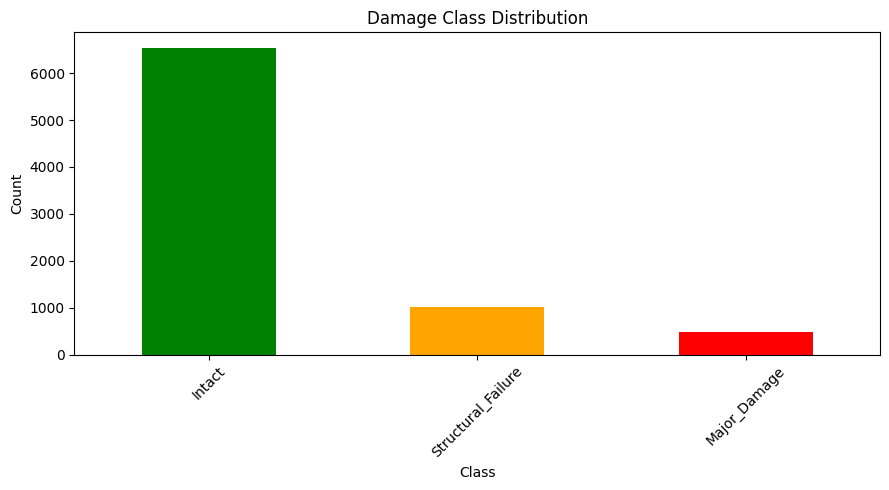

In [10]:
counts = train_df['damage_class'].value_counts()

plt.figure(figsize=(9, 5))
counts.plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Damage Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'distribution.png'))
plt.show()

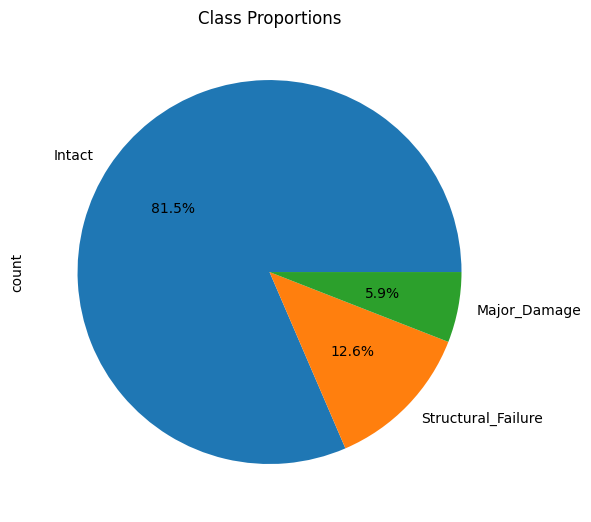

In [11]:
plt.figure(figsize=(6, 6))
counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Class Proportions')
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'proportions.png'))
plt.show()

The Intact class is completely dominant. This confirmed for me that accuracy alone would be a useless metric for this project.


## **Looking at Sample Images Per Class**

Before jumping into preprocessing I wanted to actually see what the images look like for each class. I added a standard deviation threshold check when selecting the sample so it doesn't just show me a blank or near-black image, which was happening on the first few indices I tried.

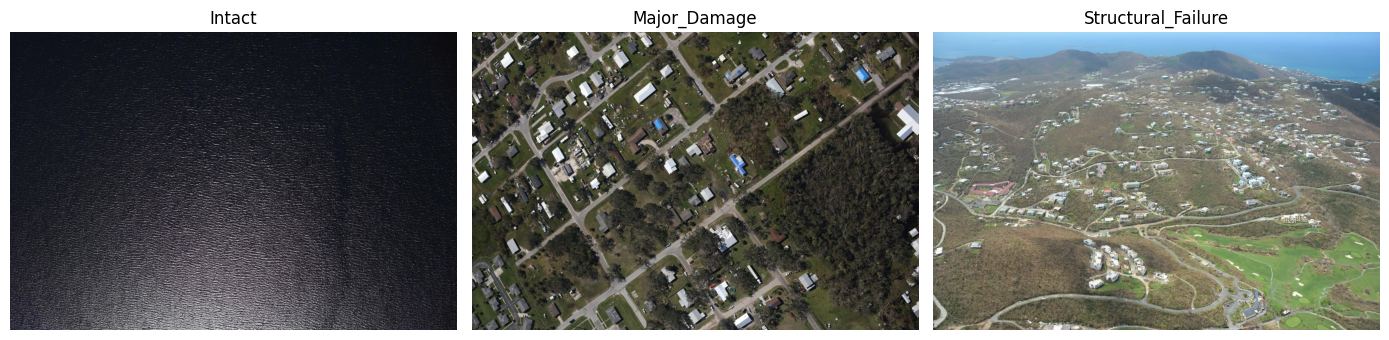

In [13]:
classes = ['Intact', 'Major_Damage', 'Structural_Failure']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, cls in enumerate(classes):
    class_indices = train_df[train_df['damage_class'] == cls].index.tolist()

    selected_img = None

    for idx in class_indices[50:150]:
        raw = ds['train'][idx]['image']

        if isinstance(raw, dict):
            img = Image.open(BytesIO(raw['bytes'])).convert('RGB')
        else:
            img = raw.convert('RGB')

        img_array = np.array(img)

        if img_array.std() > 40:
            selected_img = img
            break

    if selected_img is None:
        raw = ds['train'][class_indices[50]]['image']
        if isinstance(raw, dict):
            selected_img = Image.open(BytesIO(raw['bytes'])).convert('RGB')
        else:
            selected_img = raw.convert('RGB')

    axes[i].imshow(selected_img)
    axes[i].set_title(cls)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(base_path, 'samples_classes.png'))
plt.show()

Checking what the raw image resolution looks like before preprocessing.

In [14]:
raw = ds['train'][0]['image']
if isinstance(raw, dict):
    sample_img = Image.open(BytesIO(raw['bytes'])).convert('RGB')
else:
    sample_img = raw.convert('RGB')

print("Original image resolution:", sample_img.size[0], "x", sample_img.size[1], "pixels")
print("Images will be resized to 224 x 224 during preprocessing")

Original image resolution: 1800 x 1200 pixels
Images will be resized to 224 x 224 during preprocessing


 The original images are 1800 x 1200 pixels, which is too large to train on directly. I have resized everything to 224 x 224 during preprocessing.

## 11. Building the Preprocessing Pipeline

I built the preprocessing pipeline in four steps based on methods from published research papers that applied similar techniques to aerial and remote sensing imagery. I made sure to source each one from a specific paper and added the citations as comments in the code.

- **Gaussian Blur** — reduces sensor noise in low-altitude aerial photos while 
  keeping structural edges intact *(Hanzla et al., Frontiers 2024)*
- **Histogram Equalization on the YUV channel** — fixes contrast issues in 
  overexposed aerial images *(Hanzla et al., Frontiers 2024)*
- **HSV Color Transform** — converting from RGB to HSV separates damage color 
  signatures more clearly than RGB *(PMC HSVGLCM UAV study 2024​)*
- **Resize and Normalize** — resize to 224x224 and scale pixel values to [0,1] 
  to standardize inputs across all models *(Abdelmonem et al., 2026)*

In [ ]:
# Preprocessing Function 1 - Gaussian Blur
# Source: Hanzla et al., Frontiers 2024
def apply_gaussian(img):
    return cv2.GaussianBlur(img, (5, 5), 0)

In [ ]:
# Preprocessing Function 2 - Histogram Equalization
# Source: Hanzla et al., Frontiers 2024
def histogram_eq(img):
    img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
    img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0]) 
    return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

In [ ]:
# Preprocessing Function 3 - RGB to HSV Color Transform
# Source: PMC HSVGLCM UAV study 2024​
def color_transform(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

In [18]:
# Preprocessing Function 4 - Combined Pipeline
def preprocess_image(pil_img):
    img = np.array(pil_img.convert('RGB'))
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.resize(img, (224, 224))       
    img = apply_gaussian(img)                
    img = histogram_eq(img)                 
    img = color_transform(img)               
    img = img.astype(np.float32) / 255.0    
    return img

Running the pipeline step by step on a single image and displaying each stage so I can visually confirm what each transformation is actually doing to the image.

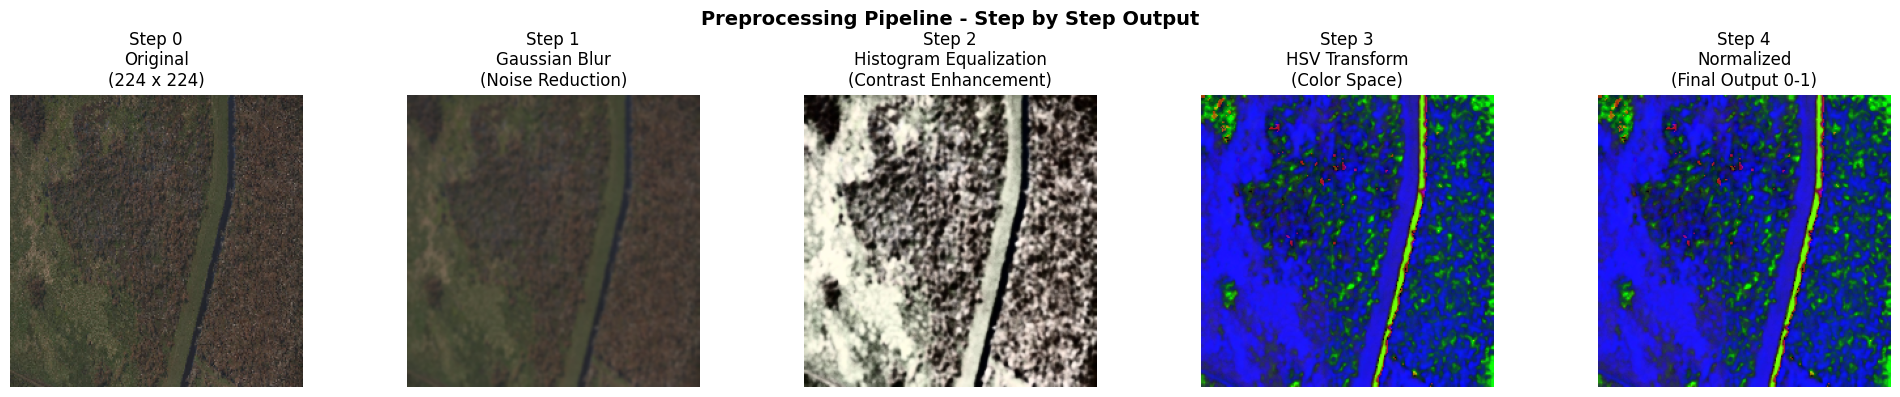

In [19]:
original_bgr = cv2.cvtColor(np.array(sample_img.convert('RGB')), cv2.COLOR_RGB2BGR)
original_bgr = cv2.resize(original_bgr, (224, 224))

step1_gaussian    = apply_gaussian(original_bgr)   
step2_histeq      = histogram_eq(step1_gaussian)    
step3_hsv         = color_transform(step2_histeq)      
step4_normalized  = step3_hsv.astype(np.float32) / 255.0 

original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].imshow(original_rgb)
axes[0].set_title('Step 0\nOriginal\n(224 x 224)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(step1_gaussian, cv2.COLOR_BGR2RGB))
axes[1].set_title('Step 1\nGaussian Blur\n(Noise Reduction)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(step2_histeq, cv2.COLOR_BGR2RGB))
axes[2].set_title('Step 2\nHistogram Equalization\n(Contrast Enhancement)')
axes[2].axis('off')

axes[3].imshow(step3_hsv)
axes[3].set_title('Step 3\nHSV Transform\n(Color Space)')
axes[3].axis('off')

axes[4].imshow(step4_normalized)
axes[4].set_title('Step 4\nNormalized\n(Final Output 0-1)')
axes[4].axis('off')

plt.suptitle('Preprocessing Pipeline - Step by Step Output', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'preprocessing_steps.png'))
plt.show()

## **Original vs Preprocessed of All Three Classes:**

Applying the full pipeline to one image from each damage class and showing original vs preprocessed side by side. I wanted to make sure the pipeline was working correctly across all three class types and not just on one image.

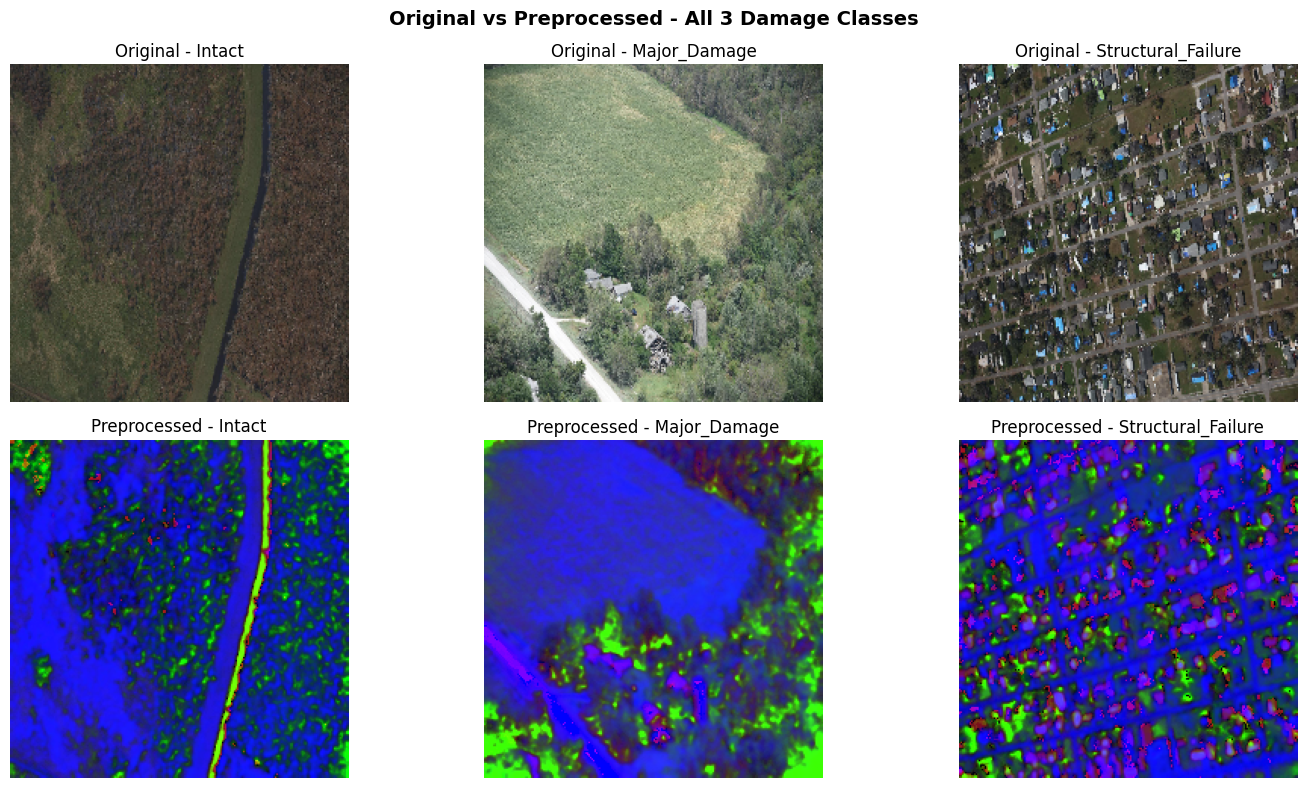

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, cls in enumerate(classes):
    idx  = train_df[train_df['damage_class'] == cls].index[0]
    raw  = ds['train'][idx]['image']

    if isinstance(raw, dict):
        img = Image.open(BytesIO(raw['bytes'])).convert('RGB')
    else:
        img = raw.convert('RGB')

    orig_disp = cv2.resize(np.array(img.convert('RGB')), (224, 224))
    processed = preprocess_image(img)

    axes[0][i].imshow(orig_disp)
    axes[0][i].set_title('Original - ' + cls)
    axes[0][i].axis('off')

    axes[1][i].imshow(processed)
    axes[1][i].set_title('Preprocessed - ' + cls)
    axes[1][i].axis('off')

plt.suptitle('Original vs Preprocessed - All 3 Damage Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base_path, 'preprocessing_classes.png'))
plt.show()

In [22]:
result = preprocess_image(sample_img)
print("Before preprocessing:", sample_img.size[0], "x", sample_img.size[1], "pixels")
print("After preprocessing: ", result.shape[1], "x", result.shape[0], "pixels")
print("Pixel range - min:", round(result.min(), 4), "max:", round(result.max(), 4))

Before preprocessing: 1800 x 1200 pixels
After preprocessing:  224 x 224 pixels
Pixel range - min: 0.0 max: 1.0


## **Saving All Preprocessed Images to Disk:**

Now running the full pipeline on every image across all three splits and saving them to the preprocessed_dataset/ folder organized by split and class. This is going to take a while so I added a progress print every 200 images to track it.

In [24]:
for split_name, split_data in [("train", ds['train']), ("validation", ds['validation']), ("test", ds['test'])]:
    csv_name = "val" if split_name == "validation" else split_name
    split_df = pd.read_csv(os.path.join(base_path, csv_name + ".csv"))

    for idx in range(len(split_data)):
        raw = split_data[idx]['image']
        if isinstance(raw, dict):
            pil_img = Image.open(BytesIO(raw['bytes'])).convert('RGB')
        else:
            pil_img = raw.convert('RGB')

        cls    = split_df.iloc[idx]['damage_class']
        folder = os.path.join(output_dir, split_name, cls)
        os.makedirs(folder, exist_ok=True)
        cv2.imwrite(os.path.join(folder, str(idx) + ".jpg"), (preprocess_image(pil_img) * 255).astype(np.uint8))
        if idx % 200 == 0:
            print(split_name, idx, "/", len(split_data))

train 0 / 8030
train 200 / 8030
train 400 / 8030
train 600 / 8030
train 800 / 8030
train 1000 / 8030
train 1200 / 8030
train 1400 / 8030
train 1600 / 8030
train 1800 / 8030
train 2000 / 8030
train 2200 / 8030
train 2400 / 8030
train 2600 / 8030
train 2800 / 8030
train 3000 / 8030
train 3200 / 8030
train 3400 / 8030
train 3600 / 8030
train 3800 / 8030
train 4000 / 8030
train 4200 / 8030
train 4400 / 8030
train 4600 / 8030
train 4800 / 8030
train 5000 / 8030
train 5200 / 8030
train 5400 / 8030
train 5600 / 8030
train 5800 / 8030
train 6000 / 8030
train 6200 / 8030
train 6400 / 8030
train 6600 / 8030
train 6800 / 8030
train 7000 / 8030
train 7200 / 8030
train 7400 / 8030
train 7600 / 8030
train 7800 / 8030
train 8000 / 8030
validation 0 / 890
validation 200 / 890
validation 400 / 890
validation 600 / 890
validation 800 / 890
test 0 / 1049
test 200 / 1049
test 400 / 1049
test 600 / 1049
test 800 / 1049
test 1000 / 1049


Checking the counts in each folder to confirm everything saved correctly before moving on to augmentation.

## **Augmenting the Training Set — Minority Classes Only:**

The class imbalance is too severe to train on as-is. I am only augmenting the two minority classes, `Major Damage and Structural Failure`, and leaving Intact completely alone. Augmenting the majority class would just make the imbalance problem worse.

The augmentation applies random flips, rotations up to 40 degrees, brightness changes between 0.7x and 1.3x, and random zoom with crop. I set the multiplier to 8x for Major Damage and 5x for Structural Failure as a starting point.


`NOTE: This Augmentation was performed after failing to resolve the class imbalance in the CNN Model training notebooks and also after using the VGG-16 Deeper architeture`

In [25]:
print("Image counts before augmentation:")
for split_name in ["train", "validation", "test"]:
    split_folder = os.path.join(output_dir, split_name)
    for cls in os.listdir(split_folder):
        count = len(os.listdir(os.path.join(split_folder, cls)))
        print(split_name, cls, count)
    print("\n")

Image counts before augmentation:
train Intact 6542
train Major_Damage 476
train Structural_Failure 1012


validation Intact 710
validation Major_Damage 65
validation Structural_Failure 115


test Intact 1001
test Major_Damage 22
test Structural_Failure 26




## **Augmenting the Validation Set:**

I also augmented the minority classes in the validation set using the same approach. Without this, the validation Macro F1 score would be calculated on only 65 Major Damage and 115 Structural Failure images, which is too small to give stable readings during training.

In [ ]:
import random

def augment_image(img_array):
    img = Image.fromarray(img_array.astype(np.uint8))

    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_TOP_BOTTOM)

    angle = random.uniform(-40, 40)
    img = img.rotate(angle, fillcolor=(0, 0, 0))

    from PIL import ImageEnhance
    factor = random.uniform(0.7, 1.3)
    img = ImageEnhance.Brightness(img).enhance(factor)

    zoom = random.uniform(0.8, 1.0)
    w, h = img.size
    new_w = int(w * zoom)
    new_h = int(h * zoom)
    left  = random.randint(0, w - new_w)
    top   = random.randint(0, h - new_h)
    img   = img.crop((left, top, left + new_w, top + new_h))
    img   = img.resize((224, 224), Image.BILINEAR)

    return np.array(img)

In [30]:
augment_targets = {
    'Major_Damage': 8,
    'Structural_Failure': 5
}

train_dir = os.path.join(output_dir, "train")

for cls, factor in augment_targets.items():
    cls_folder = os.path.join(train_dir, cls)
    existing   = [f for f in os.listdir(cls_folder) if f.endswith('.jpg')]

    print(cls, "- original count:", len(existing))

    aug_count = 0
    for fname in existing:
        img_path  = os.path.join(cls_folder, fname)
        img_array = np.array(Image.open(img_path).convert('RGB'))

        for _ in range(factor):
            aug_array = augment_image(img_array)
            save_name = "aug_" + str(aug_count) + "_" + fname
            cv2.imwrite(
                os.path.join(cls_folder, save_name),
                cv2.cvtColor(aug_array, cv2.COLOR_RGB2BGR)
            )
            aug_count += 1

    print(cls, "- new count:", len(os.listdir(cls_folder)))

Major_Damage - original count: 476
Major_Damage - new count: 4284
Structural_Failure - original count: 1012
Structural_Failure - new count: 6072


In [31]:
print("Updated training class counts after augmentation:")
for cls in ['Intact', 'Major_Damage', 'Structural_Failure']:
    cls_folder = os.path.join(train_dir, cls)
    print(cls, ":", len(os.listdir(cls_folder)), "images")

Updated training class counts after augmentation:
Intact : 6542 images
Major_Damage : 4284 images
Structural_Failure : 6072 images


In [3]:
base_path    = r"C:\Users\kesha\Desktop\MSDS-696_Practicum-2"
output_dir   = os.path.join(base_path, "preprocessed_dataset")

print("output_dir:", output_dir)
print("Validation folders:", os.listdir(os.path.join(output_dir, "validation")))

output_dir: C:\Users\kesha\Desktop\MSDS-696_Practicum-2\preprocessed_dataset
Validation folders: ['Intact', 'Major_Damage', 'Structural_Failure']


In [4]:

def augment_image(img_array):
    img = Image.fromarray(img_array.astype(np.uint8))

    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_TOP_BOTTOM)

    angle = random.uniform(-40, 40)
    img   = img.rotate(angle, fillcolor=(0, 0, 0))

    factor = random.uniform(0.7, 1.3)
    img    = ImageEnhance.Brightness(img).enhance(factor)

    zoom  = random.uniform(0.8, 1.0)
    w, h  = img.size
    new_w = int(w * zoom)
    new_h = int(h * zoom)
    left  = random.randint(0, w - new_w)
    top   = random.randint(0, h - new_h)
    img   = img.crop((left, top, left + new_w, top + new_h))
    img   = img.resize((224, 224), Image.BILINEAR)

    return np.array(img)

In [11]:
augment_targets = {
    'Major_Damage': 8,
    'Structural_Failure': 5
}

train_dir = os.path.join(output_dir, "train")

for cls, factor in augment_targets.items():
    cls_folder = os.path.join(train_dir, cls)
    existing   = [f for f in os.listdir(cls_folder)
                  if f.endswith('.jpg') and not f.startswith('aug_')]

    print(cls, "- original count:", len(existing))

    aug_count = 0
    for fname in existing:
        img_path  = os.path.join(cls_folder, fname)
        img_array = np.array(Image.open(img_path).convert('RGB'))

        for _ in range(factor):
            aug_array = augment_image(img_array)
            save_name = "aug_" + str(aug_count) + "_" + fname
            cv2.imwrite(
                os.path.join(cls_folder, save_name),
                cv2.cvtColor(aug_array, cv2.COLOR_RGB2BGR)
            )
            aug_count += 1

    print(cls, "- new count:", len(os.listdir(cls_folder)))

Major_Damage - original count: 476
Major_Damage - new count: 4284
Structural_Failure - original count: 1012
Structural_Failure - new count: 6072


In [7]:
import random
from PIL import Image, ImageEnhance

val_augment_targets = {
    'Major_Damage': 8,
    'Structural_Failure': 5
}

val_dir = os.path.join(output_dir, "validation")

for cls, factor in val_augment_targets.items():
    cls_folder = os.path.join(val_dir, cls)
    existing   = [f for f in os.listdir(cls_folder)
                  if f.endswith('.jpg') and not f.startswith('aug_')]

    print(cls, "- original count:", len(existing))

    aug_count = 0
    for fname in existing:
        img_path  = os.path.join(cls_folder, fname)
        img_array = np.array(Image.open(img_path).convert('RGB'))

        for _ in range(factor):
            aug_array = augment_image(img_array)
            save_name = "aug_" + str(aug_count) + "_" + fname
            cv2.imwrite(
                os.path.join(cls_folder, save_name),
                cv2.cvtColor(aug_array, cv2.COLOR_RGB2BGR)
            )
            aug_count += 1

    print(cls, "- new count:", len(os.listdir(cls_folder)))

Major_Damage - original count: 65
Major_Damage - new count: 585
Structural_Failure - original count: 115
Structural_Failure - new count: 690


In [8]:
def augment_image(img_array):
    img = Image.fromarray(img_array.astype(np.uint8))

    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_TOP_BOTTOM)

    angle = random.uniform(-40, 40)
    img   = img.rotate(angle, fillcolor=(0, 0, 0))

    factor = random.uniform(0.7, 1.3)
    img    = ImageEnhance.Brightness(img).enhance(factor)

    zoom  = random.uniform(0.8, 1.0)
    w, h  = img.size
    new_w = int(w * zoom)
    new_h = int(h * zoom)
    left  = random.randint(0, w - new_w)
    top   = random.randint(0, h - new_h)
    img   = img.crop((left, top, left + new_w, top + new_h))
    img   = img.resize((224, 224), Image.BILINEAR)

    return np.array(img)

In [9]:
val_augment_targets = {
    'Major_Damage': 8,
    'Structural_Failure': 5
}

val_dir = os.path.join(output_dir, "validation")

for cls, factor in val_augment_targets.items():
    cls_folder = os.path.join(val_dir, cls)
    existing   = [f for f in os.listdir(cls_folder)
                  if f.endswith('.jpg') and not f.startswith('aug_')]

    print(cls, "- original count:", len(existing))

    aug_count = 0
    for fname in existing:
        img_path  = os.path.join(cls_folder, fname)
        img_array = np.array(Image.open(img_path).convert('RGB'))

        for _ in range(factor):
            aug_array = augment_image(img_array)
            save_name = "aug_" + str(aug_count) + "_" + fname
            cv2.imwrite(
                os.path.join(cls_folder, save_name),
                cv2.cvtColor(aug_array, cv2.COLOR_RGB2BGR)
            )
            aug_count += 1

    print(cls, "- new count:", len(os.listdir(cls_folder)))

Major_Damage - original count: 65
Major_Damage - new count: 585
Structural_Failure - original count: 115
Structural_Failure - new count: 690


In [ ]:
print("Final image counts across all splits:")
print()
for split_name in ["train", "validation", "test"]:
    split_folder = os.path.join(output_dir, split_name)
    total = 0
    for cls in sorted(os.listdir(split_folder)):
        count = len(os.listdir(os.path.join(split_folder, cls)))
        print(split_name, cls, count)
        total += count
    print(split_name, "total:", total)
    print("---")

Final image counts across all splits:

train Intact 6542
train Major_Damage 4284
train Structural_Failure 6072
train total: 16898
---
validation Intact 710
validation Major_Damage 585
validation Structural_Failure 690
validation total: 1985
---
test Intact 1001
test Major_Damage 22
test Structural_Failure 26
test total: 1049
---


In [13]:
for cls in ['Intact', 'Major_Damage', 'Structural_Failure']:
    count = len(os.listdir(os.path.join(val_dir, cls)))
    print("validation", cls, count)

validation Intact 710
validation Major_Damage 585
validation Structural_Failure 690


In [14]:
cls_folder = os.path.join(train_dir, 'Structural_Failure')

existing  = [f for f in os.listdir(cls_folder)
             if f.endswith('.jpg') and not f.startswith('aug_')
             and not f.startswith('extra_')]

print("Original count:", len(existing))

aug_count = 0
for fname in existing:
    img_path  = os.path.join(cls_folder, fname)
    img_array = np.array(Image.open(img_path).convert('RGB'))

    for _ in range(5):
        aug_array = augment_image(img_array)
        save_name = "extra_" + str(aug_count) + "_" + fname
        cv2.imwrite(
            os.path.join(cls_folder, save_name),
            cv2.cvtColor(aug_array, cv2.COLOR_RGB2BGR)
        )
        aug_count += 1

print("New Structural_Failure train count:", len(os.listdir(cls_folder)))

Original count: 1012
New Structural_Failure train count: 11132


In [15]:
cls_folder = os.path.join(val_dir, 'Structural_Failure')

existing  = [f for f in os.listdir(cls_folder)
             if f.endswith('.jpg') and not f.startswith('aug_')
             and not f.startswith('extra_')]

print("Original count:", len(existing))

aug_count = 0
for fname in existing:
    img_path  = os.path.join(cls_folder, fname)
    img_array = np.array(Image.open(img_path).convert('RGB'))

    for _ in range(5):
        aug_array = augment_image(img_array)
        save_name = "extra_" + str(aug_count) + "_" + fname
        cv2.imwrite(
            os.path.join(cls_folder, save_name),
            cv2.cvtColor(aug_array, cv2.COLOR_RGB2BGR)
        )
        aug_count += 1

print("New Structural_Failure val count:", len(os.listdir(cls_folder)))

Original count: 115
New Structural_Failure val count: 1265


In [18]:
print("Final image counts across all splits:")
print()
for split_name in ["train", "validation", "test"]:
    split_folder = os.path.join(output_dir, split_name)
    total = 0
    for cls in sorted(os.listdir(split_folder)):
        count = len(os.listdir(os.path.join(split_folder, cls)))
        print(split_name, cls, count)
        total += count
    print(split_name, "total:", total)
    print("---")

Final image counts across all splits:

train Intact 6542
train Major_Damage 4284
train Structural_Failure 11132
train total: 21958
---
validation Intact 710
validation Major_Damage 585
validation Structural_Failure 1265
validation total: 2560
---
test Intact 1001
test Major_Damage 22
test Structural_Failure 26
test total: 1049
---


In [20]:
for split_name, split_dir in [("train", train_dir),
                               ("validation", val_dir),
                               ("test", test_dir)]:
    total = 0
    for cls in sorted(os.listdir(split_dir)):
        count = len(os.listdir(os.path.join(split_dir, cls)))
        print(split_name, cls, count)
        total += count
    print(split_name, "total:", total)
    print("---")

train Intact 6542
train Major_Damage 4284
train Structural_Failure 11132
train total: 21958
---
validation Intact 710
validation Major_Damage 585
validation Structural_Failure 1265
validation total: 2560
---
test Intact 1001
test Major_Damage 22
test Structural_Failure 26
test total: 1049
---


The test set is untouched as expected.

| Split | Intact | Major Damage | Structural Failure | Total |
|---|---|---|---|---|
| Train | 6,542 | 4,284 | 11,132 | 21,958 |
| Validation | 710 | 585 | 1,265 | 2,560 |
| Test | 1,001 | 22 | 26 | 1,049 |

The preprocessed and augmented dataset is now ready.